In [1]:
# Import all the necessary libraries.
import random
import matplotlib.pyplot as plt
import math
import numpy as np
import functools
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from IPython.core.display import display, HTML


np.random.seed(32)

"""
Generate data points for plotting the error surface.
"""
def calculateErrorSurface(y, x1, x2):
    # Generate values for parameter space.
    N = 200
    a1 = np.linspace(-20.0, 24.0, N)
    a2 = np.linspace(-20.0, 24.0, N)

    A1, A2 = np.meshgrid(a1, a2)

    # Generate points for plotting the cost-function surface.
    J = np.zeros((N,N))
    for iter1 in range(0, N):
        for iter2 in range(0, N):
            # h = a1*x1 + a2*x2
            yhat = A1[iter1][iter2]*x1 + A2[iter1][iter2]*x2
            J[iter1][iter2] = (1/M)*np.sum( np.square(y - yhat)  )
            
    return J, A1, A2

"""
Calculate closed-form solution using the normal equation.
"""
def calculateClosedFormSolution(X_b, x1, x2, y):
    # Closed-form solution.
    a_opt = np.linalg.pinv(np.transpose(X_b).dot(X_b)).dot(np.transpose(X_b).dot(y))
    # h = a1*x1 + a2*x2
    yhat = a_opt[0, 0]*x1 + a_opt[1, 0]*x2
    Joptimum = (1/M)*np.sum(np.power((y - yhat), 2) )
    
    return Joptimum, a_opt

"""
Batch gradient descent solution.
"""

def batchGradientDescent(alpha, n_iterations, X_b, y): 
    
    # Random initialization of parameters.
    a = np.zeros((2,1))
    a[0] = -20;
    a[1] = -20;
    
    Jgd = np.zeros(n_iterations+1)
    Jgd[0] = (1/M)*sum(np.power( (y - X_b.dot(a)) , 2))

    # Create vector for parameter history.
    a_hist = np.zeros((2, n_iterations+1))
    # Initialize history vector.
    a_hist[0, 0] = a[0]
    a_hist[1, 0] = a[1]
    
    error = 1;
    iteration = 0;
    # Batch gradient-descent loop - Critério de parada
    while(error > 0.001 and iteration < n_iterations-1):
        
        gradients = -2/M * X_b.T.dot(y - X_b.dot(a))
        a = a - alpha * gradients
        a_hist[0, iteration+1] = a[0]
        a_hist[1, iteration+1] = a[1]
        Jgd[iteration+1] = (1/M)*sum(np.power( (y - X_b.dot(a)) , 2))
        error = np.abs(Jgd[iteration]-Jgd[iteration+1])
        iteration = iteration + 1        
    return a, a_hist, Jgd
    

    
"""
Batch gradient descent para percorrer a quantidade de exemplos M=1000.
"""

def batchGradientDescent2(a, n_iterations, X_b, y): 
    
    # Random initialization of parameters.
    #a = np.zeros((2,1))
    #a[0] = -20;
    #a[1] = -20;
    
    Jgd = np.zeros(n_iterations+1)
    Jgd[0] = (1/M)*sum(np.power( (y - X_b.dot(a)) , 2))

    # Create vector for parameter history.
    #a_hist = np.zeros((2, n_iterations+1))
    # Initialize history vector.
    #a_hist[0, 0] = a[0]
    #a_hist[1, 0] = a[1]
    
    iteration = 0;
    # Batch gradient-descent loop - Critério de parada
    while(iteration < n_iterations-1):
        
        #gradients = -2/M * X_b.T.dot(y - X_b.dot(a))
        #a = a - alpha * gradients
        #a_hist[0, iteration+1] = a[0]
        #a_hist[1, iteration+1] = a[1]
        Jgd[iteration+1] = (1/M)*sum(np.power( (y - X_b.dot(a)) , 2))
        iteration = iteration + 1        
    return Jgd

"""
Hypothesis Function
"""
def h(X_b, a):
    return a.T.dot(X_b.T)


#-----------------------------------------------------------------------------------------

np.random.seed(32)
# Number of examples.
M = 1000

media_x1 = 0
desvioPadrao_x1 = 1


media_x2 = 10
desvioPadrao_x2 = 10

x1 = np.random.normal(media_x1, desvioPadrao_x1, (M, 1))
x2 = np.random.normal(media_x2, desvioPadrao_x2, (M, 1))
y = x1 + x2


np.random.seed(99)

x1T = np.random.normal(media_x1, desvioPadrao_x1, (M, 1))
x2T = np.random.normal(media_x2, desvioPadrao_x2, (M, 1))


yT = x1T + x2T

X_b = np.c_[x1, x2]

n_iterations = 2000

# Batch gradient descent solution.
alpha1 = 0.001  # learning rate
alpha2 = 1.3
alpha3 = 0.5
alpha4 = 0.9
alpha5 = 0.5

X_bT = np.c_[x1T, x2T]

In [2]:
# Calculate data point for plotting error surface.
J, A1, A2 = calculateErrorSurface(y, x1, x2)

# Calculate closed-form solution.
Joptimum, a_opt = calculateClosedFormSolution(X_b, x1, x2, y)


# Run batch gradient-descent algorithm.
a, a_hist, Jgd = batchGradientDescent(alpha1, n_iterations, X_b, y)

# Run batch gradient-descent algorithm.
#a, a_hist, Jgd = batchGradientDescent2(alpha1, n_iterations, X_b, y)

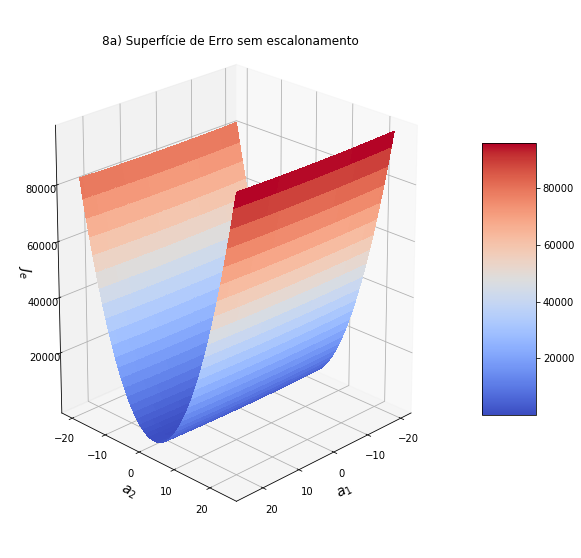

In [3]:
# Plote da Superfície de Erro sem escalonamento.
fig = plt.figure(figsize=(10,10))
ax = fig.gca(projection='3d')
surf = ax.plot_surface(A1, A2, J, cmap=cm.coolwarm, linewidth=0, antialiased=False)
# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)
ax.set_xlabel('$a_1$', fontsize=14)
ax.set_ylabel('$a_2$', fontsize=14)
ax.set_zlabel('$J_e$', fontsize=14);
plt.title('8a) Superfície de Erro sem escalonamento')
ax.view_init(20, 45)
plt.show()

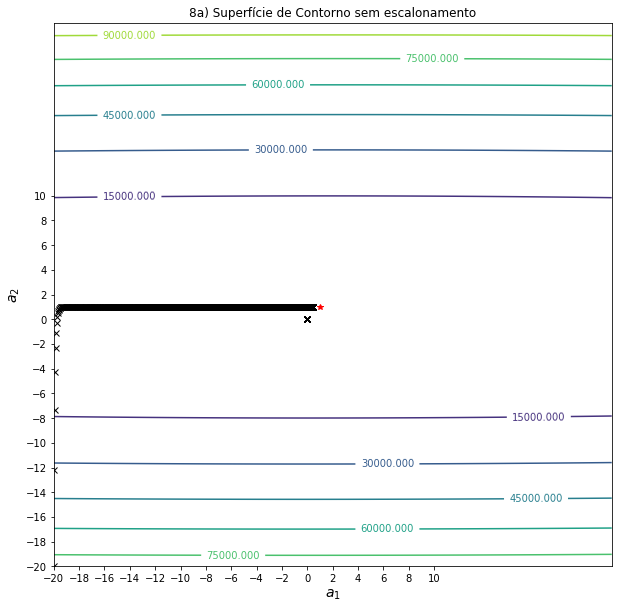

In [4]:
# Plote da Superfície de Contorno sem escalonamento.        
fig = plt.figure(figsize=(10,10))
cp = plt.contour(A1, A2, J)
plt.clabel(cp, inline=1, fontsize=10)
plt.xlabel('$a_1$', fontsize=14)
plt.ylabel('$a_2$', fontsize=14)
plt.title('8a) Superfície de Contorno sem escalonamento')
plt.plot(a_opt[0], a_opt[1], c='r', marker='*')
plt.plot(a_hist[0, :], a_hist[1, :], 'kx')
plt.xticks(np.arange(-20, 12, step=2.0))
plt.yticks(np.arange(-20, 12, step=2.0))
plt.show()

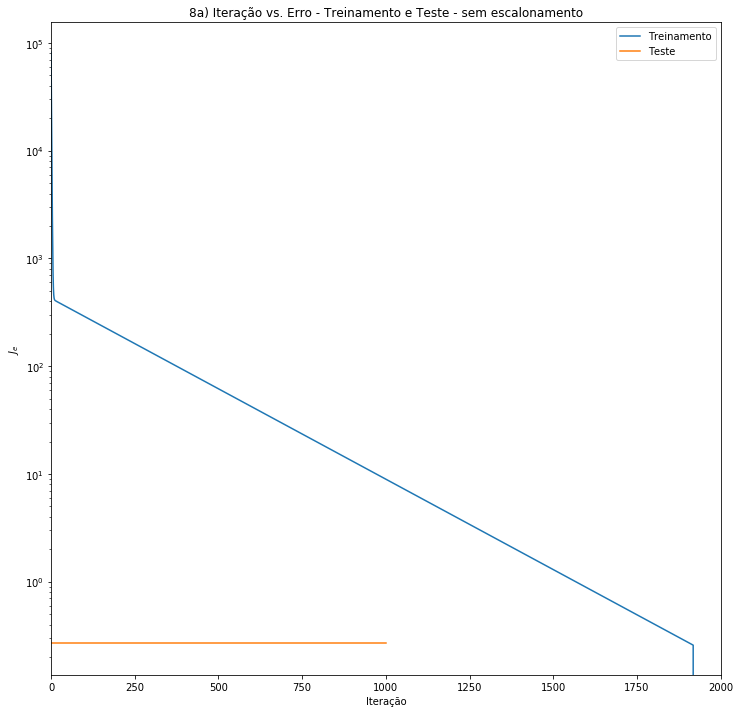

In [5]:
 # Run batch gradient-descent algorithm.
#a, a_hist, Jgd = batchGradientDescent(alpha1, n_iterations, X_b, y) Treinamento
JgdT = batchGradientDescent2(a, 1000, X_bT, yT) # Teste

# Plote da Iteração vs. Erro sem escalonamento. 
fig = plt.figure(figsize=(12,12))
plt.plot(np.arange(0, n_iterations), Jgd[0:n_iterations], label= 'Treinamento')
plt.plot(np.arange(0, 1000), JgdT[0:1000], label = 'Teste')
plt.xlim((0, n_iterations))
plt.yscale('log')
plt.xlabel('Iteração')
plt.ylabel('$J_e$')
plt.title('8a) Iteração vs. Erro - Treinamento e Teste - sem escalonamento')
plt.legend()
plt.show()

In [6]:
# --- Geração de dados de Treinamento com Min_Max nas Features de Treinamento. ---
minx1 = np.amin(x1)
maxx1 = np.amax(x1)

x1_Min_Max = np.array(np.ones((M, 1))) 

for i, item in enumerate(x1):
    x1_Min_Max[i,0] = (item - minx1) / (maxx1 - minx1)
    
minx2 = np.amin(x2)
maxx2 = np.amax(x2)

x2_Min_Max = np.array(np.ones((M, 1))) 

for i, item in enumerate(x2):
    x2_Min_Max[i,0] = (item - minx2) / (maxx2 - minx2)
    
X_Min_Max = np.c_[x1_Min_Max, x2_Min_Max]
X_b_Min_Max = X_Min_Max

#y = x1 + x2

# --- Geração de dados de TESTE com Min_Max nas Features de Teste. ---
x1T_Min_Max = np.array(np.ones((M, 1)))
for i, item in enumerate(x1T):
    x1T_Min_Max[i,0] = (item - minx1) / (maxx1 - minx1)

x2T_Min_Max = np.array(np.ones((M, 1)))
for i, item in enumerate(x2T):
    x2T_Min_Max[i,0] = (item - minx2) / (maxx2 - minx2)

XT_Min_Max = np.c_[x1T_Min_Max, x2T_Min_Max]
X_bT_Min_Max = XT_Min_Max    
    
#yT = x1T + x2T

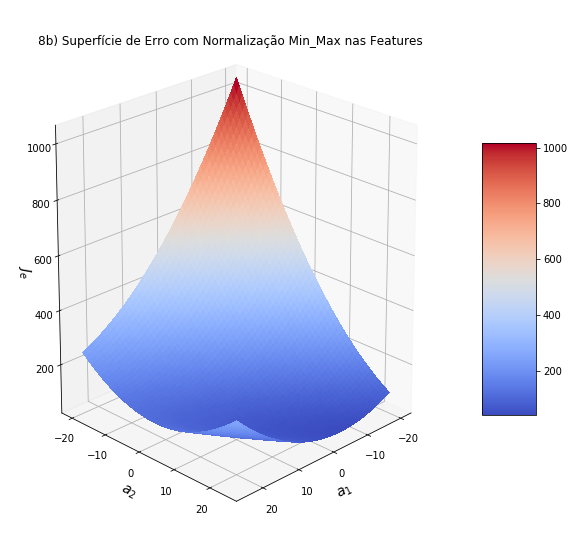

In [7]:
# Plote da Superfície de Erro de Treinamento com Min_Max nas Features.

# Calculate data point for plotting error surface.
J_Min_Max, A1_Min_Max, A2_Min_Max = calculateErrorSurface(y, x1_Min_Max, x2_Min_Max)

fig = plt.figure(figsize=(10,10))
ax = fig.gca(projection='3d')
surf = ax.plot_surface(A1_Min_Max, A2_Min_Max, J_Min_Max, cmap=cm.coolwarm, linewidth=0, antialiased=False)
# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)
ax.set_xlabel('$a_1$', fontsize=14)
ax.set_ylabel('$a_2$', fontsize=14)
ax.set_zlabel('$J_e$', fontsize=14);
plt.title('8b) Superfície de Erro com Normalização Min_Max nas Features')
ax.view_init(20, 45)
plt.show()

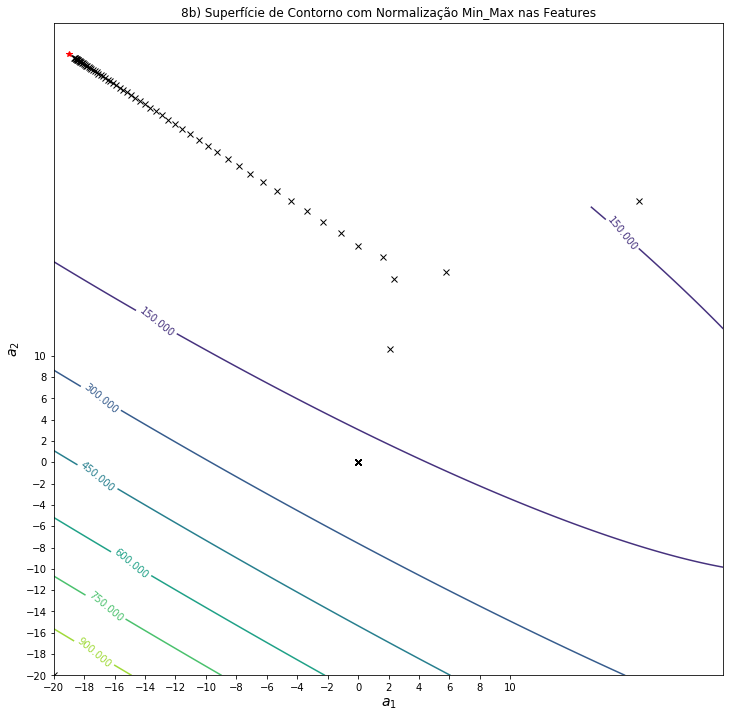

In [8]:
# Plote da Superfície de Contorno de Treinamento com Min_Max nas Features.

# Calculate closed-form solution.
Joptimum_Min_Max, a_opt_Min_Max = calculateClosedFormSolution(X_b_Min_Max, x1_Min_Max, x2_Min_Max, y)

# Run batch gradient-descent algorithm.
a_Min_Max, a_hist_Min_Max, Jgd_Min_Max = batchGradientDescent(alpha2, n_iterations, X_b_Min_Max, y)

fig = plt.figure(figsize=(12,12))
cp = plt.contour(A1_Min_Max, A2_Min_Max, J_Min_Max)
plt.clabel(cp, inline=1, fontsize=10)
plt.xlabel('$a_1$', fontsize=14)
plt.ylabel('$a_2$', fontsize=14)
plt.title('8b) Superfície de Contorno com Normalização Min_Max nas Features')
plt.plot(a_opt_Min_Max[0], a_opt_Min_Max[1], c='r', marker='*')
plt.plot(a_hist_Min_Max[0, :], a_hist_Min_Max[1, :], 'kx')
plt.xticks(np.arange(-20, 12, step=2.0))
plt.yticks(np.arange(-20, 12, step=2.0))
plt.show()

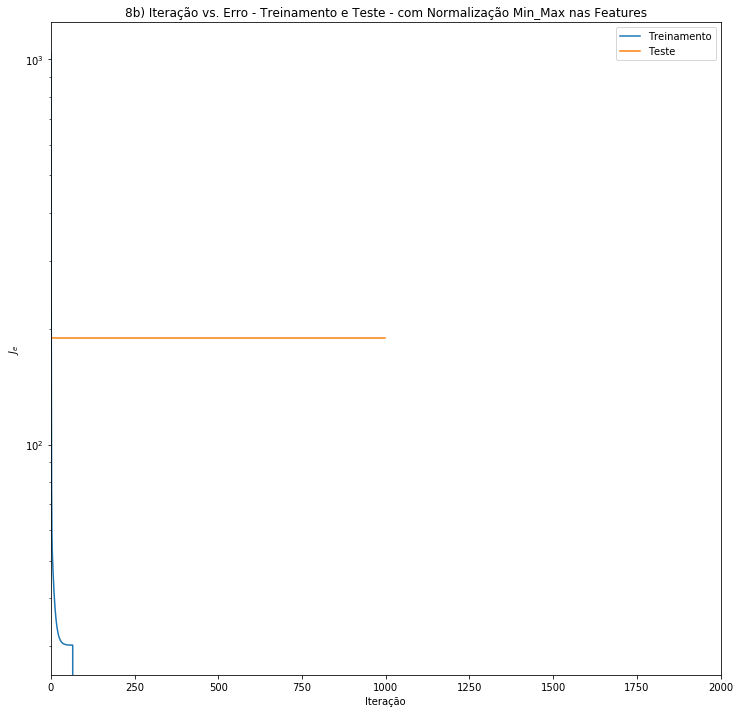

In [9]:
# Run batch gradient-descent algorithm.

# Run batch gradient-descent algorithm Train.
a_Min_Max, a_hist_Min_Max, Jgd_Min_Max = batchGradientDescent(alpha2, n_iterations, X_b_Min_Max, y)

# Run batch gradient-descent algorithm Test.
JgdT_Min_Max = batchGradientDescent2(a, 1000, X_bT_Min_Max, yT)

# Plote da Iteração vs. Erro. 
fig = plt.figure(figsize=(12,12))
plt.plot(np.arange(0, n_iterations), Jgd_Min_Max[0:n_iterations], label= 'Treinamento')
plt.plot(np.arange(0, 1000), JgdT_Min_Max[0:1000], label= 'Teste')
plt.xlim((0, n_iterations))
plt.yscale('log')
plt.xlabel('Iteração')
plt.ylabel('$J_e$')
plt.title('8b) Iteração vs. Erro - Treinamento e Teste - com Normalização Min_Max nas Features')
plt.legend()
plt.show()


In [10]:
# --- Geração de dados de Treinamento com PADRONIZAÇAO nas Features. ---

x1_pad = np.array(np.ones((M, 1))) 

for i, item in enumerate(x1):
    x1_pad[i,0] = (item - 0) / 1
    
x2_pad = np.array(np.ones((M, 1))) 

for i, item in enumerate(x2):
    x2_pad[i,0] = (item - 10) / 10
    
X_pad = np.c_[x1_pad, x2_pad]
X_b_pad = X_pad
    
#y = x1+x2

# --- Geração de dados de TESTE com Padronizaçao nas Features. ---

x1T_pad = np.array(np.ones((M, 1))) 

for i, item in enumerate(x1T):
    x1T_pad[i,0] = (item - 0) / 1
    
x2T_pad = np.array(np.ones((M, 1))) 

for i, item in enumerate(x2T):
    x2T_pad[i,0] = (item - 10) / 10

XT_pad = np.c_[x1T_pad, x2T_pad]
X_bT_pad = XT_pad
#yT = x1T + x2T

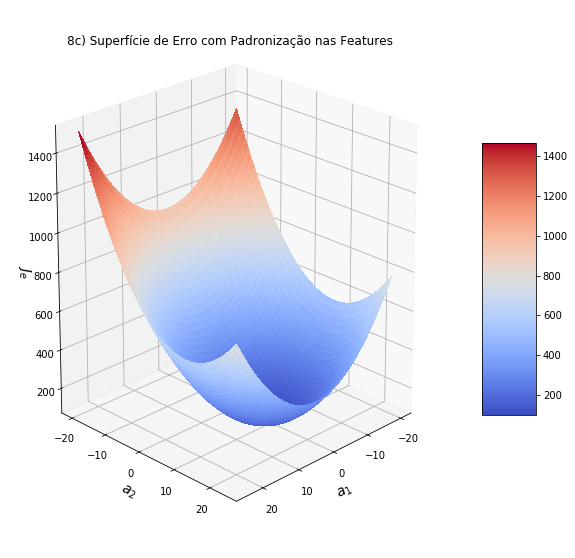

In [11]:
# Plote da Superfície de Erro de Treinamento com PADRONIZAÇAO nas Features.

# Calculate data point for plotting error surface.
J_pad, A1_pad, A2_pad = calculateErrorSurface(y, x1_pad, x2_pad)

fig = plt.figure(figsize=(10,10))
ax = fig.gca(projection='3d')
surf = ax.plot_surface(A1_pad, A2_pad, J_pad, cmap=cm.coolwarm, linewidth=0, antialiased=False)
# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)
ax.set_xlabel('$a_1$', fontsize=14)
ax.set_ylabel('$a_2$', fontsize=14)
ax.set_zlabel('$J_e$', fontsize=14);
plt.title('8c) Superfície de Erro com Padronização nas Features')
ax.view_init(20, 45)
plt.show()

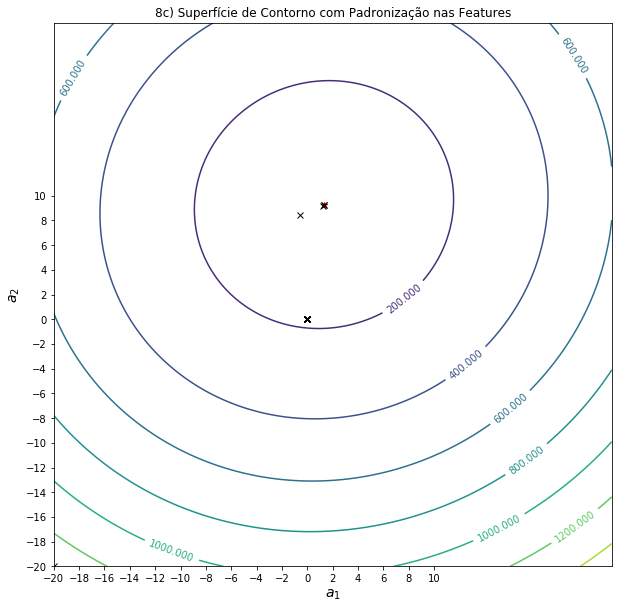

In [12]:
# Plote da Superfície de Contorno de Treinamento com PADRONIZAÇAO nas Features. 

# Calculate closed-form solution.
Joptimum_pad, a_opt_pad = calculateClosedFormSolution(X_b_pad, x1_pad, x2_pad, y)

# Run batch gradient-descent algorithm.
a_pad, a_hist_pad, Jgd_pad = batchGradientDescent(alpha3, n_iterations, X_b_pad, y)

fig = plt.figure(figsize=(10,10))
cp = plt.contour(A1_pad, A2_pad, J_pad)
plt.clabel(cp, inline=1, fontsize=10)
plt.xlabel('$a_1$', fontsize=14)
plt.ylabel('$a_2$', fontsize=14)
plt.title('8c) Superfície de Contorno com Padronização nas Features')
plt.plot(a_opt_pad[0], a_opt_pad[1], c='r', marker='*')
plt.plot(a_hist_pad[0, :], a_hist_pad[1, :], 'kx')
plt.xticks(np.arange(-20, 12, step=2.0))
plt.yticks(np.arange(-20, 12, step=2.0))
plt.show()

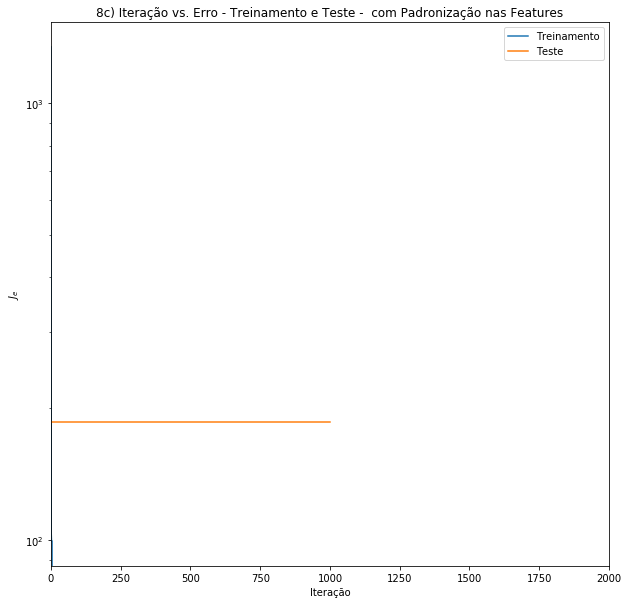

In [13]:
# Plote da Superfície de Contorno de Treinamento com PADRONIZAÇAO nas Features. 

# Run batch gradient-descent algorithm Train.
#a_pad, a_hist_pad, Jgd_pad = batchGradientDescent(alpha3, n_iterations, X_b_pad, y)

# Run batch gradient-descent algorithm Test.
JgdT_pad = batchGradientDescent2(a, 1000, X_bT_pad, yT)

# Plote da Iteração vs. Erro de Treinamento com PADRONIZAÇAO.
fig = plt.figure(figsize=(10,10))
plt.plot(np.arange(0, n_iterations), Jgd_pad[0:n_iterations], label= 'Treinamento')
plt.plot(np.arange(0, 1000), JgdT_pad[0:1000], label= 'Teste')
plt.xlim((0, n_iterations))
plt.yscale('log')
plt.xlabel('Iteração')
plt.ylabel('$J_e$')
plt.title('8c) Iteração vs. Erro - Treinamento e Teste -  com Padronização nas Features')
plt.legend()
plt.show()

In [14]:
# --- Geração de dados de Treinamento com Min_Max em  Rótulos-Y. ---

y_Min_Max = x1_Min_Max + x2_Min_Max

# --- Geração de dados de TESTE com Min_Max em Rótulos-Y. ---

yT_Min_Max = x1T_Min_Max + x2T_Min_Max

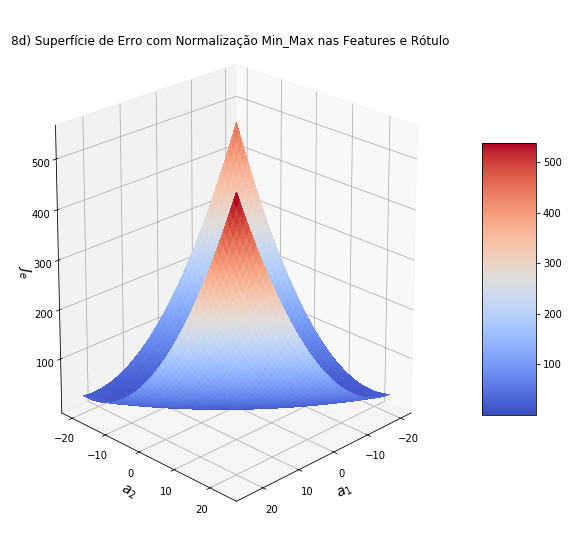

In [15]:
# Plote da Superfície de Erro de Treinamento com Min_Max em Rótulos-Y

# Calculate data point for plotting error surface.
J_Min_Max, A1_Min_Max, A2_Min_Max = calculateErrorSurface(y_Min_Max, x1_Min_Max, x2_Min_Max)

fig = plt.figure(figsize=(10,10))
ax = fig.gca(projection='3d')
surf = ax.plot_surface(A1_Min_Max, A2_Min_Max, J_Min_Max, cmap=cm.coolwarm, linewidth=0, antialiased=False)
# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)
ax.set_xlabel('$a_1$', fontsize=14)
ax.set_ylabel('$a_2$', fontsize=14)
ax.set_zlabel('$J_e$', fontsize=14);
plt.title('8d) Superfície de Erro com Normalização Min_Max nas Features e Rótulo')
ax.view_init(20, 45)
plt.show()

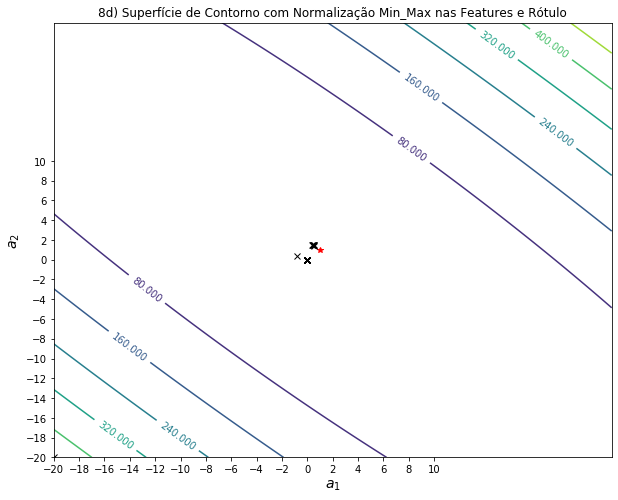

In [16]:
# Plote da Superfície de Contorno de Treinamento com Min_Max em Rótulos-Y

# Calculate closed-form solution.
Joptimum_Min_Max, a_opt_Min_Max = calculateClosedFormSolution(X_b_Min_Max, x1_Min_Max, x2_Min_Max, y_Min_Max)

# Run batch gradient-descent algorithm.
a_Min_Max, a_hist_Min_Max, Jgd_Min_Max = batchGradientDescent(alpha4, n_iterations, X_b_Min_Max, y_Min_Max)


fig = plt.figure(figsize=(10,8))
cp = plt.contour(A1_Min_Max, A2_Min_Max, J_Min_Max)
plt.clabel(cp, inline=1, fontsize=10)
plt.xlabel('$a_1$', fontsize=14)
plt.ylabel('$a_2$', fontsize=14)
plt.title('8d) Superfície de Contorno com Normalização Min_Max nas Features e Rótulo')
plt.plot(a_opt_Min_Max[0], a_opt_Min_Max[1], c='r', marker='*')
plt.plot(a_hist_Min_Max[0, :], a_hist_Min_Max[1, :], 'kx')
plt.xticks(np.arange(-20, 12, step=2.0))
plt.yticks(np.arange(-20, 12, step=2.0))
plt.show()

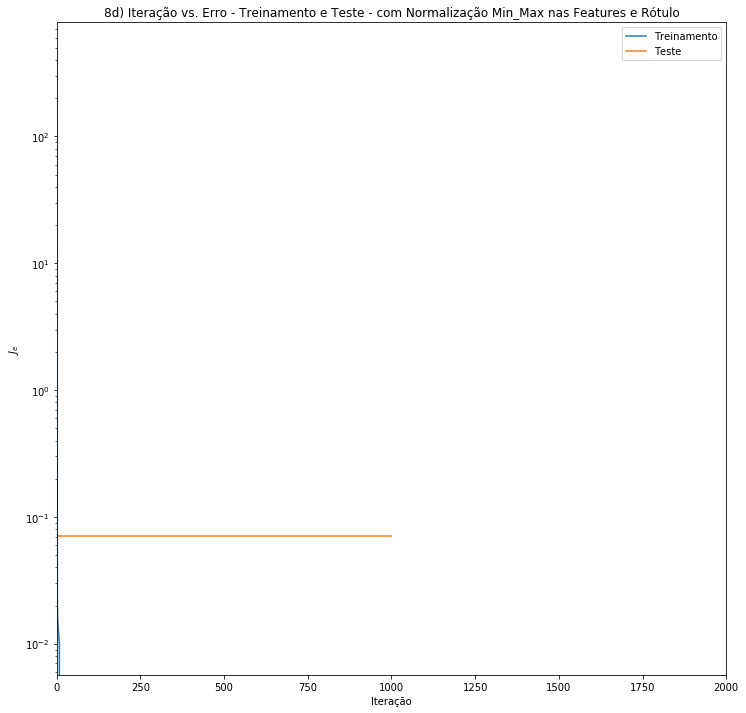

In [17]:
# Run batch gradient-descent algorithm.
#a_Min_Max, a_hist_Min_Max, Jgd_Min_Max = batchGradientDescent(alpha4, n_iterations, X_b_Min_Max, y_Min_Max)

JgdT_Min_Max = batchGradientDescent2(a, 1000, X_bT_Min_Max, yT_Min_Max)
#print(yT_Min_Max)

# Plote da Iteração vs. Erro. 
fig = plt.figure(figsize=(12,12))
plt.plot(np.arange(0, n_iterations), Jgd_Min_Max[0:n_iterations], label= 'Treinamento')
plt.plot(np.arange(0, 1000), JgdT_Min_Max[0:1000], label= 'Teste')
plt.xlim((0, n_iterations))
plt.yscale('log')
plt.xlabel('Iteração')
plt.ylabel('$J_e$')
plt.title('8d) Iteração vs. Erro - Treinamento e Teste - com Normalização Min_Max nas Features e Rótulo')
plt.legend()
plt.show()

In [18]:
# --- Geração de dados de Treinamento com PADRONIZAÇAO em Rótulos-Y. ---
    
y_pad = x1_pad + x2_pad

# --- Geração de dados de TESTE com PADRONIZAÇAO em Rótulos-Y. ---

yT_pad = x1T_pad + x2T_pad

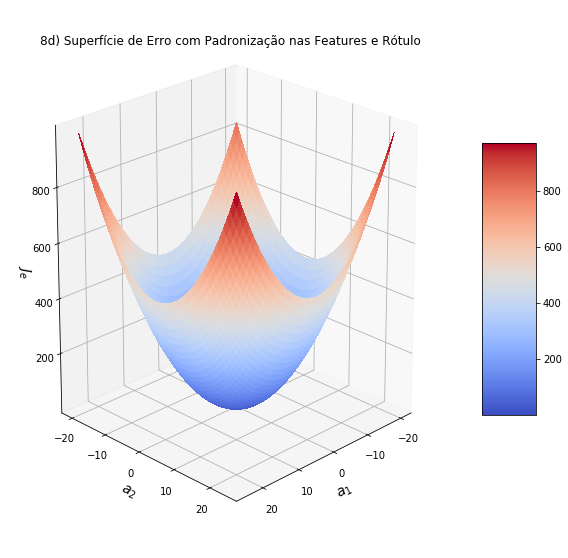

In [19]:
# Plote da Superfície de Erro de Treinamento com PADRONIZAÇAO em Rótulos-Y.

# Calculate data point for plotting error surface.
J_pad, A1_pad, A2_pad = calculateErrorSurface(y_pad, x1_pad, x2_pad)

fig = plt.figure(figsize=(10,10))
ax = fig.gca(projection='3d')
surf = ax.plot_surface(A1_pad, A2_pad, J_pad, cmap=cm.coolwarm, linewidth=0, antialiased=False)
# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)
ax.set_xlabel('$a_1$', fontsize=14)
ax.set_ylabel('$a_2$', fontsize=14)
ax.set_zlabel('$J_e$', fontsize=14);
plt.title('8d) Superfície de Erro com Padronização nas Features e Rótulo')
ax.view_init(20, 45)
plt.show()

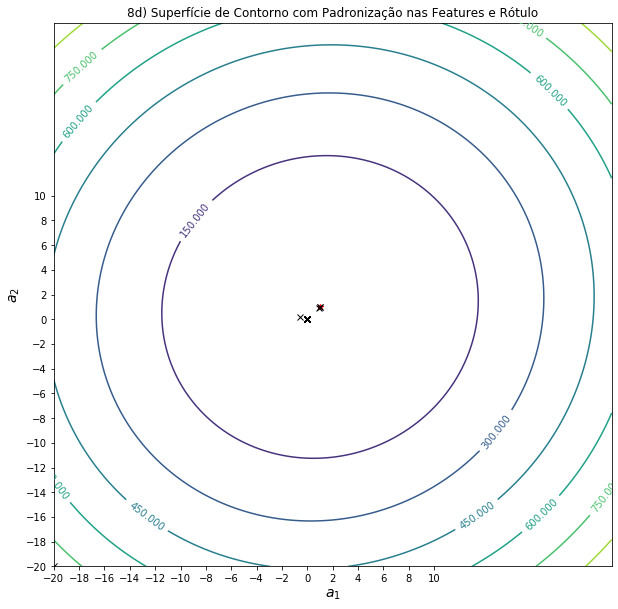

In [20]:
# Plote da Superfície de Contorno de Treinamento com PADRONIZAÇAO em Rótulos-Y. 

# Calculate closed-form solution.
Joptimum_pad, a_opt_pad = calculateClosedFormSolution(X_b_pad, x1_pad, x2_pad, y_pad)

# Run batch gradient-descent algorithm.
a_pad, a_hist_pad, Jgd_pad = batchGradientDescent(alpha5, n_iterations, X_b_pad, y_pad)

# Calculate data point for plotting error surface.
#J_pad, A1_pad, A2_pad = calculateErrorSurface(y_pad, x1_pad, x2_pad)

fig = plt.figure(figsize=(10,10))
cp = plt.contour(A1_pad, A2_pad, J_pad)
plt.clabel(cp, inline=1, fontsize=10)
plt.xlabel('$a_1$', fontsize=14)
plt.ylabel('$a_2$', fontsize=14)
plt.title('8d) Superfície de Contorno com Padronização nas Features e Rótulo')
plt.plot(a_opt_pad[0], a_opt_pad[1], c='r', marker='*')
plt.plot(a_hist_pad[0, :], a_hist_pad[1, :], 'kx')
plt.xticks(np.arange(-20, 12, step=2.0))
plt.yticks(np.arange(-20, 12, step=2.0))
plt.show()

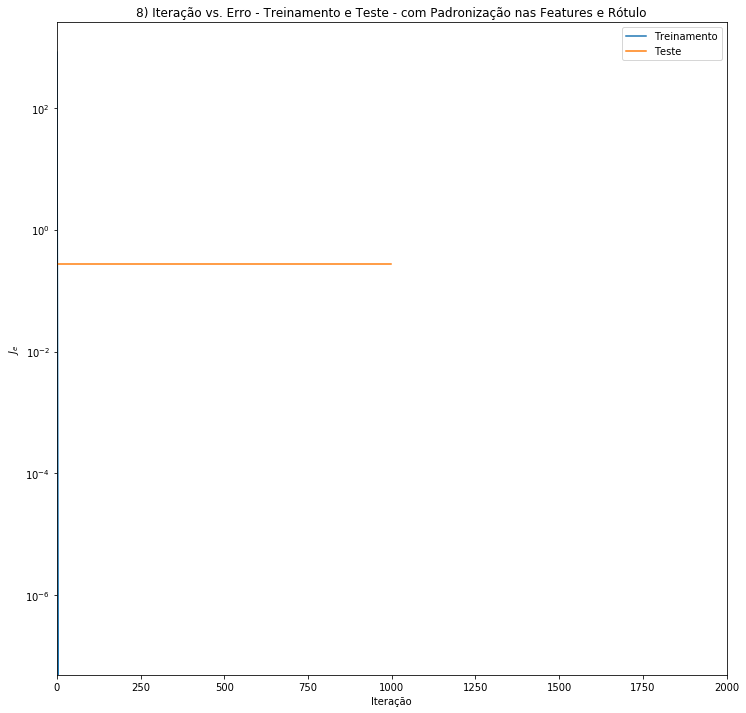

In [21]:
# Run batch gradient-descent algorithm.
#a_pad, a_pad, Jgd_pad = batchGradientDescent(alpha5, n_iterations, X_b_pad, y_pad)

JgdT_pad = batchGradientDescent2(a, 1000, X_bT_pad, yT_pad)

# Plote da Iteração vs. Erro de Treinamento com PADRONIZAÇAO.
fig = plt.figure(figsize=(12,12))
plt.plot(np.arange(0, n_iterations), Jgd_pad[0:n_iterations], label= 'Treinamento')
plt.plot(np.arange(0, 1000), JgdT_pad[0:1000], label= 'Teste')
plt.xlim((0, n_iterations))
plt.yscale('log')
plt.xlabel('Iteração')
plt.ylabel('$J_e$')
plt.title('8) Iteração vs. Erro - Treinamento e Teste - com Padronização nas Features e Rótulo')
plt.legend()
plt.show()

 8e) **Baseado nos resultados anteriores o que você pode concluir a respeito do escalonamento de features?
    (​Dica​: Comente a respeito das formas das superfícies de erro, dos números de iterações necessárias 
    para se alcançar o ponto ótimo, isso se ele é alcançado, da diferença entre o erro quadrático médio              
    obtido para o conjunto de treinamento e o obtido para o conjunto de testes (são similares ou diferentes), 
    da diferença entre os valores do erro quadrático médio para os 3 casos acima, i.e., sem escalonamento e 
     com os 2 tipos de escalonamento com e sem escalonamento dos labels (qual resulta no menor erro? 
    Escalonar os labels traz algum benefício? Como ficam as superfícies de erro quando se escalona os labels?), 
    e o que mais você achar interessante comentar. Quanto mais detalhada sua análise dos resultados, melhor será sua
    avaliação neste exercício.)**
    
**Resposta:**    
O Escalonamento de features é fundamental para ajustar valores numéricos de escalas diferentes e é um forte auxiliador para se atingir a convergência do valor ótimo. Pois a máquina que irá ser treinada não sabe distinguir unidades. Por exemplo, diferenciar Kilogramas(unidade de peso) de Metros (unidade de cumprimento/distância). A máquina percebe que o número de maior valor escalar tem maior importância em relação a um número escalar menor.

Com isso a seguir estão descritas as análises feitas nas representações gráficas aqui plotadas:

[1]-> **O gráfico da superfície de erro sem escalonamento** com alpha1 = 0.001, mostra uma curva em formato de U e uma superficie de contorno em forma de linhas horizontais. 
O gráfico de Iteração vs. Erro do Treinamento e Teste, deu um erro abaixo de 10^3 com menos de 2000 iterações para o treinamento respeitando a condição de parada. E um erro abaixo de 10^0 constante com 1000 iterações para o teste. 
Não conseguiu atingir o ponto ótimo.

[2]-> **O gráfico da Superfície de Erro com escalonamento de Normalização Min_Max nas Features** com alpha2 = 1.3, mostra uma figura em formato de losango e a superfície de contorno se mostra de forma diagonal esquerda. 
O gráfico de Iteração vs. Erro do Treinamento e Teste, deu um erro abaixo de 10^2 com menos de 2000 iterações para o treinamento respeitando a condição de parada. E deu um erro abaixo de 10^3 constante com 1000 iterações para o teste. 
Não conseguiu atingir o ponto ótimo.

[3]-> **O gráfico da Superfície de Erro com escalonamento de Padrozinação nas Features** com alpha3 = 0.5, mostra uma figura em formato médio de tigela e uma superfície de contorno circular. O gráfico de Iteração vs. Erro do Treinamento e Teste, deu um erro abaixo de 10^2 com menos de 2000 iterações para o Treinamento respeitando a condição de parada.
E deu um erro abaixo de 10^3 constante com 1000 iterações para o Teste. 
Alcançou o ponto ótimo após 5 iterações.

[4]-> **O gráfico da Superfície de Erro com escalonamento de Normalização Min_Max nas Features e Rótulo** com alpha4 = 0.9, mostra uma figura em formato de losango dobrado pela metade formando uma figura triângular, a superfície de contorno se mostra de forma diagonal esquerda. O gráfico de Iteração vs. Erro do Treinamento e Teste, deu um erro abaixo de 10^(-2) com menos de 2000 iterações para o treinamento respeitando a condição de parada. E deu um erro abaixo de 10^(-1) constante com 1000 iterações para o Teste. Após 9 iterações não conseguiu atingir o ponto ótimo.

[5]-> **O gráfico da Superfície de Erro com escalonamento de Padrozinação nas Features  e Rótulo** com alpha5 = 0.5, mostra uma figura em formato de tigela e uma superfície de contorno circular. O gráfico de Iteração vs. Erro do Treinamento e Teste, **deu um erro bem próximo de zero para os dados de treinamento, e deu um erro abaixo de 10^0 constante** com 1000 iterações para o Teste. Alcançou o ponto ótimo após 5 iterações.

**qual resulta no menor erro quadrático médio?**
--> o que resulta no menor erro quadrático médio é o que usa o escalonamento de Padrozinação nas Features e Rótulo.

**Escalonar os labels traz algum benefício?**
--> sim, traz grande benéficios para se atingir a convergência e diminuição do erro.

**Como ficam as superfícies de erro quando se escalona os labels?**
--> O gráfico da Superfície de Erro com escalonamento de Normalização Min_Max nas Features e Rótulo, mostra uma figura em formato de losango dobrado pela metade formando uma figura triângular.

--> O gráfico da Superfície de Erro com escalonamento de Padrozinação nas Features e Rótulo, mostra uma figura em formato de tigela com superfície de contorno circular.

**Em relação as representações gráficas mencionadas acima posso dizer que a superfície de erro ao chegar num formato de tigela a superfície de contorno foi se tornando cada vez mais circular consequentemente o erro quadratico médio diminuiu e se conseguiu atingir a convergência do ponto ótimo ao se aplicar o escalonamento nas features e rótulo no modelo de treinamento.**